# Проектная работа №2. Сжатие изображений с использованием алгоритма кластеризации методом К-средних

## Теоретическая часть

### Что такое кластеризация K-средних?

**Кластеризация K-средних (K-means clustering)** – это один из наиболее широко используемых алгоритмов неконтролируемого машинного обучения, который формирует кластеры данных на основе сходства между экземплярами данных

Для работы этого конкретного алгоритма необходимо заранее определить количество кластеров. K в K-средних означает количество кластеров. Алгоритм K-средних начинается со случайного выбора значения центроида для каждого кластера.

### Основной принцип работы алгоритма

После инициализации алгоритм итеративно выполняет три шага:

1. **Найти евклидово расстояние** между каждым экземпляром данных и центроидами всех кластеров
2. **Назначить экземпляры данных** кластеру центроида с ближайшим расстоянием
3. **Вычислить новые значения центроидов** на основе средних значений координат всех экземпляров данных из соответствующего кластера

## Практический пример

### Пример использования алгоритма

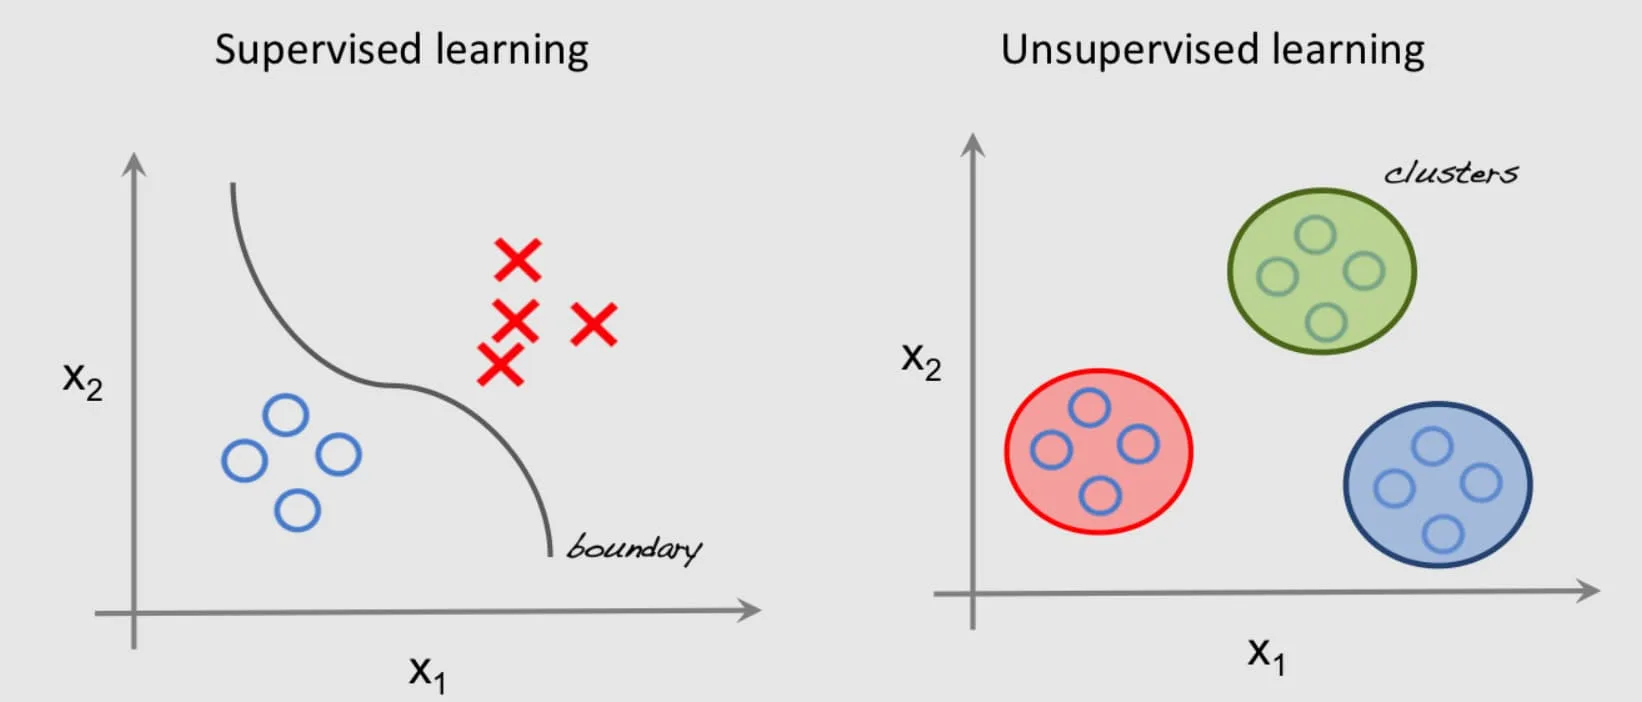

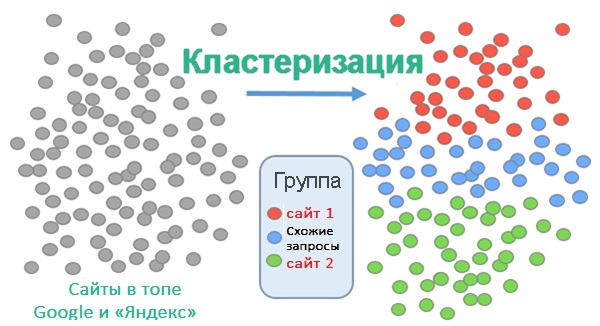

### **Визуализация процесса кластеризации**

Метод k-средних пытается сгруппировать похожие элементы в несколько этапов:


**Шаг 1:** Выбираем значение k (количество кластеров)


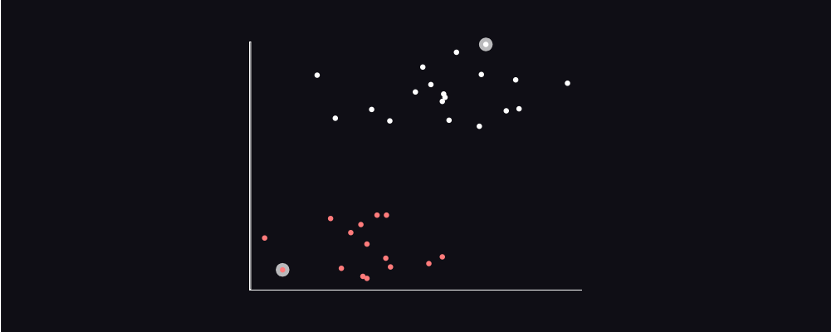

**Шаг 2:** Инициализируем центроиды


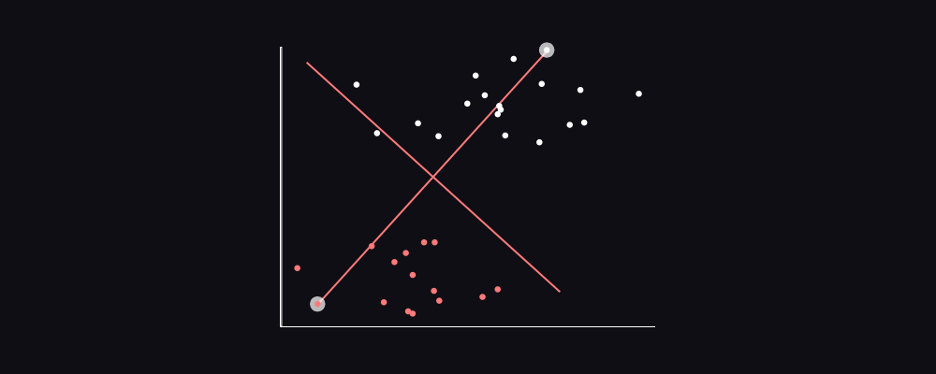

**Шаг 3:** Итеративно уточняем положение центроидов


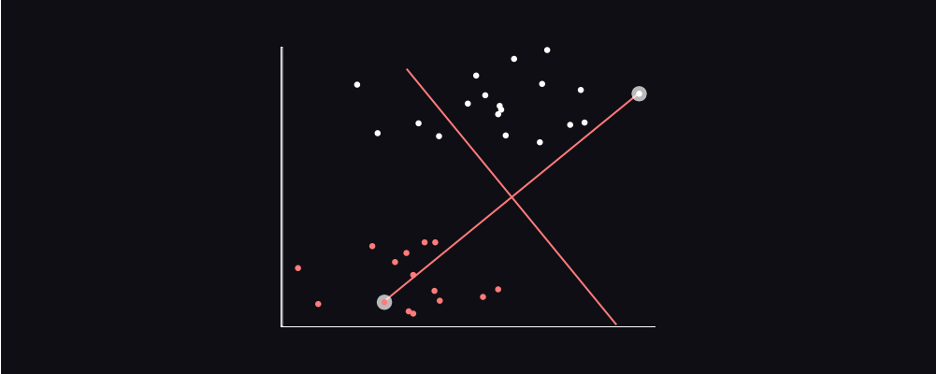





Процесс продолжается до тех пор, пока не достигнется стабильность центроидов. Стабильность определяется путем сравнения абсолютного значения среднего евклидова расстояния между наблюдениями и их соответствующими центроидами с пороговым значением.

---

#### **Еще раз простыми словами о работе алгоритма:**



1. **Начало**: Выбираем $ k $ точек, которые будут начальным представлением наших кластеров (центроидами).
2. **Разделение данных**: Проходим по всем данным и для каждой точки определяем, к какому центроиду она ближе всего. Таким образом, мы "разбиваем" данные на кластеры.
3. **Пересчет центроидов**: Для каждого полученного кластера вычисляем новый центроид — среднее значение всех точек в этом кластере.
4. **Повторение**: С новыми центроидами снова повторяем процесс: назначаем точки кластерам и пересчитываем центроиды.
5. **Завершение**: Процесс повторяется до тех пор, пока положения центроидов не перестанут существенно изменяться.

![](http://shabal.in/visuals/kmeans/left.gif)

## **Преимущества и недостатки K-means**

### Преимущества:

- Простота реализации и понимания
- Масштабируемость до огромных наборов данных
- Быстрая скорость обучения на новых примерах
- Эффективность вычислений

### Недостатки:

- Не гарантируется достижение глобального минимума
- Результат зависит от начальной инициализации центроидов
- Число кластеров необходимо знать заранее
- Чувствительность к выбросам

---

## Применение K-means для сжатия RGB изображений

При работе с цветными изображениями каждый пиксель представляется как точка в трёхмерном пространстве RGB, где:
- **R (Red)** - интенсивность красного канала (0-255)
- **G (Green)** - интенсивность зелёного канала (0-255)  
- **B (Blue)** - интенсивность синего канала (0-255)

#### Пошаговый процесс кластеризации для RGB изображений:

**Шаг 1: Преобразование изображения в набор данных**
- Изображение размером H×W×3 преобразуется в массив (H×W)×3
- Каждая строка представляет один пиксель с тремя значениями RGB
- Получаем облако точек в 3D пространстве цветов

**Шаг 2: Нормализация данных**
- Значения RGB масштабируются из диапазона [0, 255] в [0, 1]
- Это обеспечивает равномерное влияние всех каналов на расстояние

**Шаг 3: Инициализация K центроидов**
- Случайно выбираются K точек из данных как начальные центроиды
- Каждый центроид представляет собой RGB-цвет (r, g, b)

**Шаг 4: Назначение пикселей кластерам**
- Для каждого пикселя вычисляется евклидово расстояние до всех центроидов:
  ```
  d = sqrt((r₁-r₂)² + (g₁-g₂)² + (b₁-b₂)²)
  ```
- Пиксель присваивается кластеру с минимальным расстоянием

**Шаг 5: Обновление центроидов**
- Для каждого кластера вычисляется новый центроид как среднее арифметическое RGB-значений всех пикселей кластера:
  ```
  новый_центроид = (mean(R_values), mean(G_values), mean(B_values))
  ```

**Шаг 6: Проверка сходимости**
- Если центроиды не изменились (или изменились незначительно), алгоритм останавливается
- Иначе возвращаемся к Шагу 4

**Шаг 7: Замена цветов**
- Каждый пиксель заменяется цветом своего центроида
- Изображение теперь содержит только K уникальных цветов

### Ручная реализация алгоритма K-means

Теперь, когда мы разобрались с принципом работы, реализуем алгоритм самостоятельно:

In [ ]:
!curl -o image.jpg https://2spalnika.ru/wp-content/uploads/2022/12/zhivotniy-mir-hibin-800x600.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  103k  100  103k    0     0   114k      0 --:--:-- --:--:-- --:--:--  114k


```
ФУНКЦИЯ kmeans_image_compression(изображение, K, макс_итераций):
    // Подготовка данных
    пиксели = преобразовать_в_массив(изображение)  // H×W×3 → (H×W)×3
    пиксели_норм = нормализовать(пиксели)           // [0,255] → [0,1]
    
    // Инициализация
    центроиды = выбрать_случайные_точки(пиксели_норм, K)
    метки = массив_нулей(количество_пикселей)
    
    ДЛЯ итерация ОТ 1 ДО макс_итераций:
        старые_центроиды = копировать(центроиды)
        
        // Шаг назначения
        ДЛЯ каждый пиксель В пиксели_норм:
            расстояния = []
            ДЛЯ каждый центроид В центроиды:
                расст = евклидово_расстояние(пиксель, центроид)
                добавить(расстояния, расст)
            метка = индекс_минимума(расстояния)
            присвоить_метку(пиксель, метка)
        
        // Шаг обновления центроидов
        ДЛЯ k ОТ 0 ДО K-1:
            пиксели_кластера = выбрать_пиксели_с_меткой(пиксели_норм, k)
            ЕСЛИ пиксели_кластера не пустой:
                центроиды[k] = среднее(пиксели_кластера)
        
        // Проверка сходимости
        ЕСЛИ расстояние(старые_центроиды, центроиды) < порог:
            ПРЕРВАТЬ
    
    // Замена цветов
    сжатое_изображение = создать_пустое_изображение(размер_оригинала)
    ДЛЯ каждый пиксель, метка В пиксели, метки:
        сжатое_изображение[позиция] = центроиды[метка] * 255
    
    ВЕРНУТЬ сжатое_изображение
```

In [ ]:
def kmeans_image_compression(image, K=2, max_iters=100, tolerance = 1e-2):
    origanal_shape = image.shape

    pixels = image.reshape((image.shape[0]*image.shape[1]), image.shape[-1])

    pixels = pixels.astype(np.float64) / 255.0

    random_indices = np.random.choice(pixels.shape[0], K, replace=False)

    centriods = pixels[random_indices]
    labels = np.zeros(pixels.shape[0])

    for i in range(max_iters):
        old_centroids = centriods.copy()
        dist = np.linalg.norm(pixels[:, np.newaxis] - centriods, axis=2)
        labels = np.argmin(dist, axis=1)

        for k in range(K):
            clusters_pixel = pixels[labels == k]
            if len(clusters_pixel) > 0:
                centriods[k] = np.mean(clusters_pixel, axis = 0)

        diff = np.linalg.norm(centriods-old_centroids)
        if diff < tolerance:
            print(f"Сходимость наступила с {i} итерации.")
            break

    compressed_pixels = centriods[labels]

    compressed_pixels = (compressed_pixels.reshape(origanal_shape) * 255).astype(np.uint8)

    return compressed_pixels


Сходимость наступила с 18 итерации.


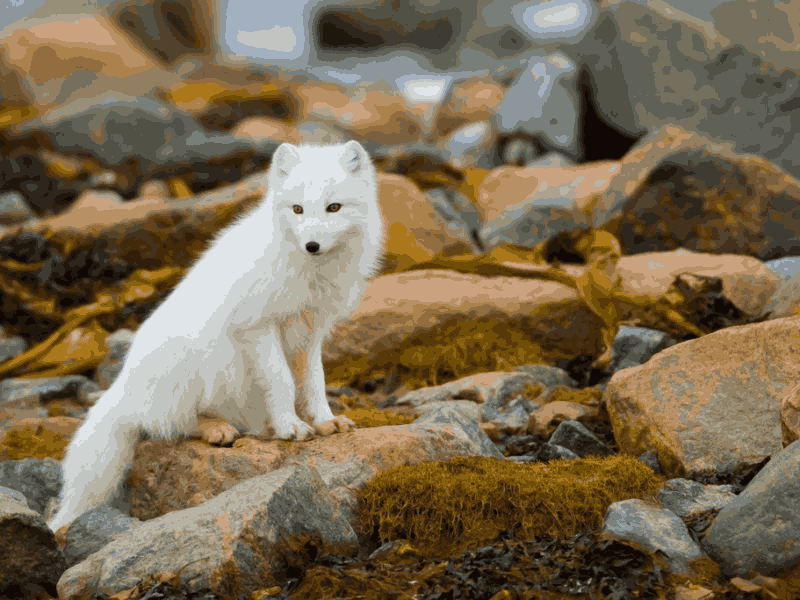

In [ ]:
# Загрузка изображения
img = cv2.imread('/content/image.jpg')  # Вводим исходное изображение

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_c = kmeans_image_compression(img, 32)

img_c = cv2.cvtColor(img_c, cv2.COLOR_RGB2BGR)

cv2_imshow(img_c)

In [ ]:
imgC = kmeans_image_compression(img)
imgC = cv2.cvtColor(imgC, cv2.COLOR_RGB2BGR)



cv2.imwrite('compressed_manual.jpg', imgC)

Сходимость наступила с 4 итерации.


True

### Реализация с использованием Scikit-learn

После того как мы разобрались с принципом работы и реализовали алгоритм вручную, рассмотрим использование готовой оптимизированной библиотеки:

Img's shape:  (600, 800, 3)
New shape (img_r):  (480000, 3)
Compressed image's shape:  (600, 800, 3)


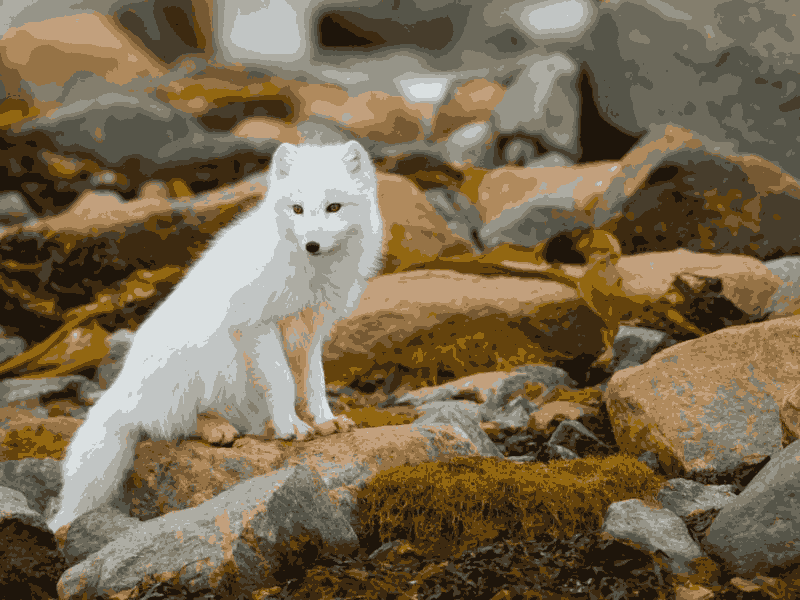

True

In [ ]:
from sklearn.cluster import KMeans
import cv2
import numpy as np
import imutils
from google.colab.patches import cv2_imshow

# Загрузка изображения
img = cv2.imread('/content/image.jpg')  # Вводим исходное изображение
print("Img's shape: ", img.shape)  # Выводим параметры начального изображения

# Нормализация и преобразование формы
# Из X×Y×3 в (X*Y)×3
img_r = (img / 255.0).reshape(-1, 3)  # Нормализуем изображение
print("New shape (img_r): ", img_r.shape)  # Выводим параметры нормализованного изображения

# Кластеризация с помощью K-means
k_colors = KMeans(n_clusters=16).fit(img_r)  # Устанавливаем количество цветов и запускаем кластеризацию

# Замена исходных цветов центроидами
imgC = k_colors.cluster_centers_[k_colors.labels_]

# Восстановление исходной формы и денормализация
imgC = (np.reshape(imgC, img.shape) * 255).astype(np.uint8)  # Возвращаем изображению исходные параметры
print("Compressed image's shape: ", imgC.shape)

# Визуализация результатов
cv2_imshow(imgC)

# Сохранение результата
cv2.imwrite('Compressed.jpg', imgC)  # сохранение сжатого изображения

### Оптимизированное сохранение с использованием палитрового режима

Для достижения максимального сжатия важно правильно сохранять изображение. При малом количестве цветов эффективнее использовать палитровый режим PNG:

In [ ]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import cv2

def compress_image_with_palette(img_path, n_colors=16):
    # Загрузка и подготовка изображения
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Нормализация и reshape
    img_r = (img_rgb / 255.0).reshape(-1, 3)

    # Кластеризация
    kmeans = KMeans(n_clusters=n_colors, random_state=42)
    kmeans.fit(img_r)

    # Получение сжатого изображения
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    # Восстановление изображения
    compressed = centers[labels].reshape(img.shape)
    compressed = (compressed * 255).astype(np.uint8)

    # Конвертация в PIL Image
    pil_img = Image.fromarray(compressed)

    # ВАЖНО: Конвертация в палитровый режим
    if n_colors <= 256:
        # Преобразование в режим P (палитровый)
        pil_img = pil_img.convert('P', palette=Image.ADAPTIVE, colors=n_colors)

        # Определение битности на основе количества цветов
        if n_colors <= 2:
            bits = 1
        elif n_colors <= 4:
            bits = 2
        elif n_colors <= 16:
            bits = 4
        else:
            bits = 8

        # Сохранение в PNG с оптимизацией
        pil_img.save(f'compressed_{n_colors}_colors.png',
                     'PNG',
                     optimize=True,
                     bits=bits)
    else:
        # Для более 256 цветов используем обычный PNG с компрессией
        pil_img.save(f'compressed_{n_colors}_colors.png',
                     'PNG',
                     optimize=True,
                     compress_level=9)

    return pil_img

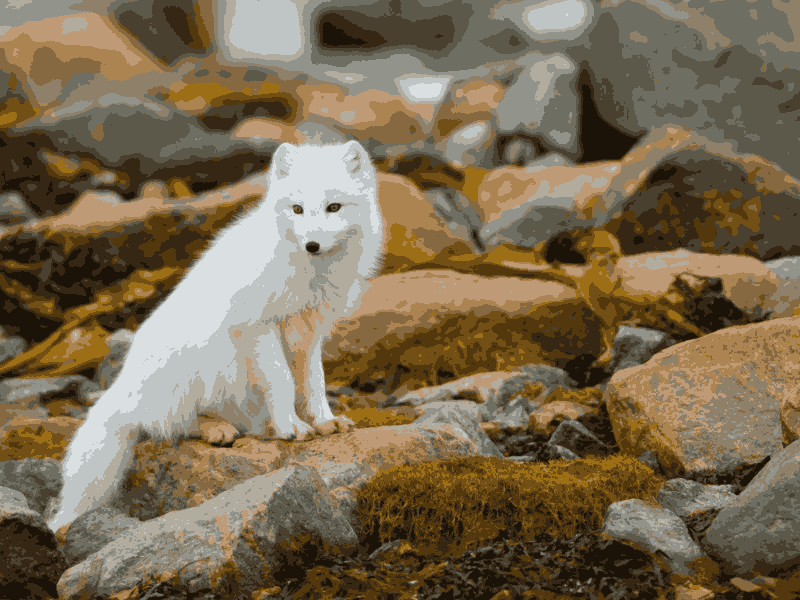

In [ ]:
compress_image_with_palette('/content/image.jpg')

> **Преимущества палитрового режима:**
> - Значительное уменьшение размера файла для изображений с малым количеством цветов
> - Точное сохранение цветов после кластеризации без дополнительных потерь
> - Автоматическая оптимизация битности в зависимости от количества цветов

---

## Применение в глубоком обучении и машинном зрении

В алгоритмах глубокого обучения метод k-средних иногда применяют не по прямому назначению (классификация разбивкой на кластеры), а для создания так называемых фильтров (ядер свёртки, словарей).

**Процесс создания фильтров:**
1. Из обучающей выборки извлекаются случайные фрагменты изображений (например, 16×16 пикселей)
2. Каждый фрагмент преобразуется в линейный вектор
3. Применяется K-means с большим K (например, 256)
4. Центроиды становятся базисными элементами для представления изображений
5. Полученные центроиды используются как ядра свёртки в CNN

---

## Реализация с контролем итераций

Как следует из определения, процесс кластеризации будет продолжаться до полной сходимости. При обработке изображений с высоким разрешением и большим количеством кластеров программа может выполняться довольно долго.

Для ускорения процесса представлена реализация с возможностью вручную указать количество итераций:

In [ ]:
import numpy as np
import matplotlib
from PIL import Image

def kmeans(Input, K, Max_iters):

    N, D = np.shape(Input)
    R = np.random.permutation(N)
    Kvec = Input[R[0:K], :]
    Distance = np.zeros((N, K))

    for nn in range(0, Max_iters):
        F = np.zeros((N, K))
        for kk in range(0, K):
            Distance[:, kk] = np.sum(np.square(Input - np.tile(Kvec[kk, :], (N, 1)), dtype=np.float64), axis=1)
        Dmin = Distance.argmin(axis=1) % Distance.shape[1]
        for mm in range(0, K):
            if np.size(Dmin[mm == Dmin]) > 0:
                Kvec[mm, :] = np.mean(Input[mm == Dmin], axis=0)
        for ii in range(0, N):
            F[ii, Dmin[ii]] = 1
        error = sum(sum((F * Distance) / N))
        print('Error = ' + str(error))
    return Kvec, Dmin


Datain = np.asarray(Image.open('/content/image.jpg'), dtype=np.float64)

ReshapedData = np.reshape(Datain, (np.size(Datain, 0) * np.size(Datain, 1), np.size(Datain, 2)))

K = 10  # устанавливаем количество цветов
Max_iters = 15  # устанавливаем количество итераций

Kvec, Dmin = kmeans(ReshapedData, K, Max_iters)

Dvec = np.zeros((len(Dmin), len(Kvec[0, :])))

for jj in range(0, K):
    Dvec[jj == Dmin, :] = Kvec[jj, :]

imout = np.reshape(np.uint8(Dvec), (np.size(Datain, 0), np.size(Datain, 1), len(Kvec[0, :])))

im = Image.fromarray(imout, 'RGB')
im.show()
im.save('output.jpeg', "JPEG", optimize=True)

Error = 2422.7712145832156
Error = 889.1051232934237
Error = 687.3216693863448
Error = 614.4242850022948
Error = 584.727434347542
Error = 569.6334100071874
Error = 559.1025481518288
Error = 551.3484388407425
Error = 545.6064922296397
Error = 541.5608213757433
Error = 538.9795724005601
Error = 537.439503600337
Error = 536.4905832516065
Error = 535.9431256448163
Error = 535.6209774171554


/tmp/ipython-input-3051316274.py:43: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray(imout, 'RGB')


> **Важно:** Количество итераций напрямую влияет на баланс между скоростью выполнения и качеством результата.

---

## Задания для выполнения

### Задание 1. Сжатие с использованием Scikit-learn

Сжать исходное изображение используя метод K-means, встроенный в библиотеку Scikit-learn при следующих вариантах количества цветов: **2, 3, 4, 8, 16, 32, 64, 128, 256**.

- Сохранить получившиеся изображения в отдельную папку `Scikit_Compressor`
- Продемонстрировать все изображения в отчёте
- Измерить и записать время выполнения для каждого случая

In [ ]:
import time
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import os
import matplotlib.pyplot as plt

In [ ]:
color_counts = [2, 3, 4, 8, 16, 32, 64, 128, 256]

In [ ]:
color_counts = [2, 3, 4, 8, 16, 32, 64, 128, 256]
results_scikit = []

for k in color_counts:
    start = time.time()

    # Нормализация и преобразование формы
    img_r = (img / 255.0).reshape(-1, 3)

    # KMeans кластеризация
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(img_r)
    new_colors = kmeans.cluster_centers_[labels]

    # Восстановление формы
    imgC = (new_colors.reshape(img.shape) * 255).astype(np.uint8)
    end = time.time()

    # Сохранение результата
    out_path = f'Scikit_Compressor/Compressed_{k}.jpg'
    cv2.imwrite(out_path, imgC)

    # Метрики
    psnr_val = psnr(cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
                    cv2.cvtColor(imgC, cv2.COLOR_BGR2RGB))
    ssim_val = ssim(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
                    cv2.cvtColor(imgC, cv2.COLOR_BGR2GRAY))

    size_kb = os.path.getsize(out_path) / 1024
    time_taken = end - start

    results_scikit.append((k, size_kb, time_taken, psnr_val, ssim_val))

    print(f"✅ {k} цветов: {round(size_kb,1)} KB, время: {round(time_taken,2)} c, PSNR={psnr_val:.2f}, SSIM={ssim_val:.3f}")


✅ 2 цветов: 106.8 KB, время: 0.26 c, PSNR=17.61, SSIM=0.534
✅ 3 цветов: 149.6 KB, время: 0.43 c, PSNR=19.96, SSIM=0.594
✅ 4 цветов: 166.7 KB, время: 0.35 c, PSNR=21.52, SSIM=0.658
✅ 8 цветов: 211.0 KB, время: 0.54 c, PSNR=24.62, SSIM=0.746
✅ 16 цветов: 214.8 KB, время: 1.2 c, PSNR=27.60, SSIM=0.827
✅ 32 цветов: 209.1 KB, время: 5.01 c, PSNR=30.25, SSIM=0.887
✅ 64 цветов: 198.3 KB, время: 4.99 c, PSNR=32.64, SSIM=0.928
✅ 128 цветов: 185.9 KB, время: 21.1 c, PSNR=34.74, SSIM=0.955
✅ 256 цветов: 176.4 KB, время: 31.98 c, PSNR=36.64, SSIM=0.969


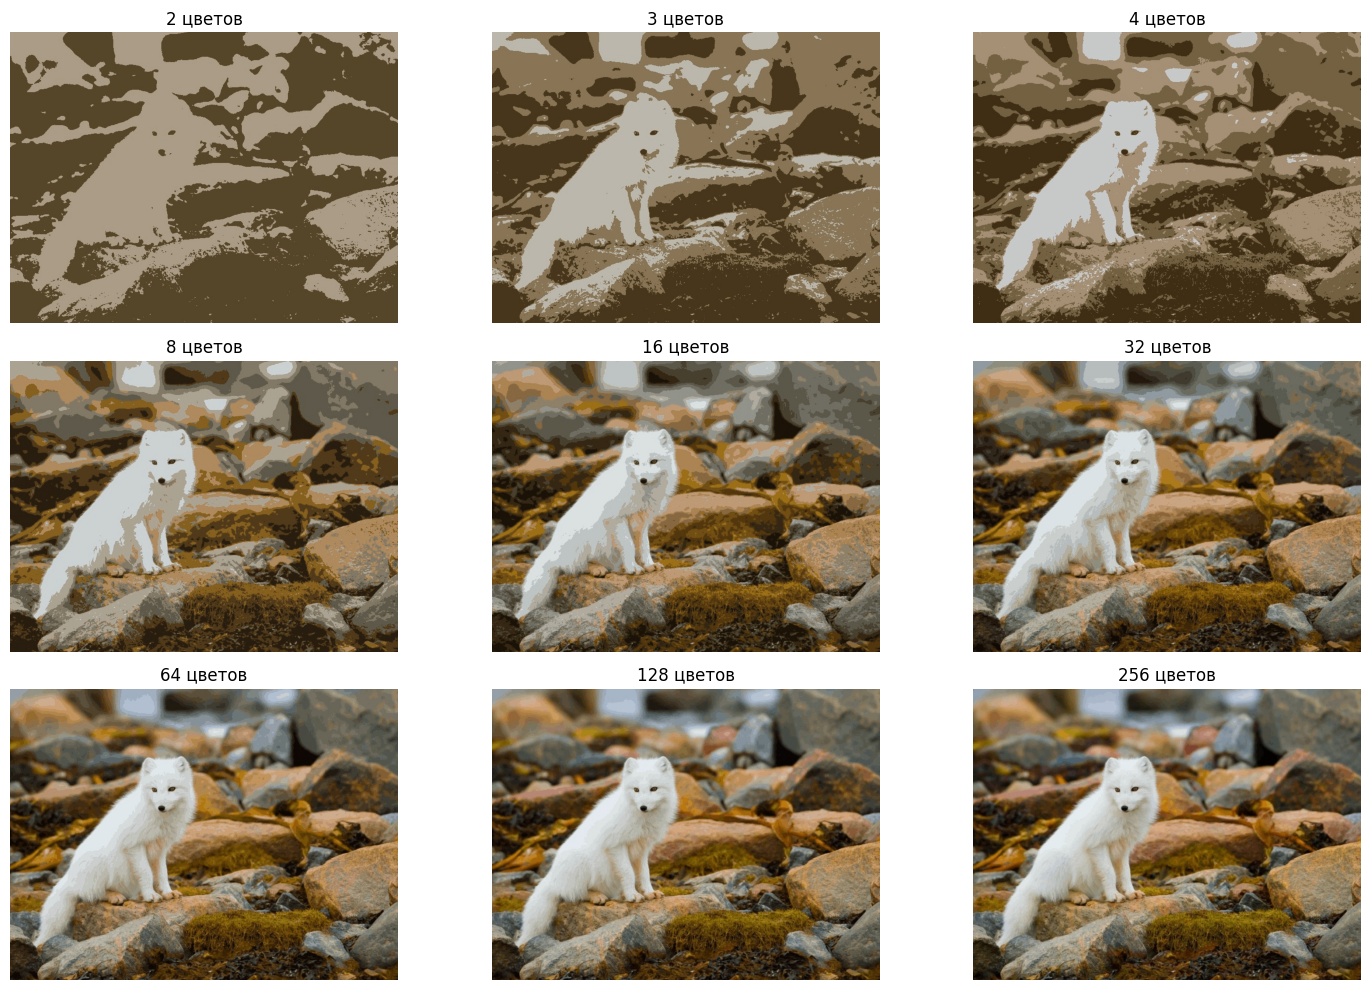

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, k in enumerate(color_counts):
    img_show = cv2.imread(f'Scikit_Compressor/Compressed_{k}.jpg')
    axes[i].imshow(img_show)
    axes[i].set_title(f'{k} цветов')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Задание 2. Оптимизация количества итераций

Используя алгоритм с ручным контролем итераций:

1. Подобрать оптимальное количество итераций по критериям:
   - Скорость выполнения
   - Качество сжатого изображения
2. Произвести сжатие с теми же количествами цветов, что и в Задании 1
3. Сохранить результаты в папку `K-means_Compressor`
4. Продемонстрировать изображения в отчёте

In [ ]:
results_custom = []

for k in color_counts:
    start = time.time()
    imgC = kmeans_image_compression(img, K=k, max_iters=4)
    end = time.time()

    out_path = f'Kmeans_Compressor/Custom_{k}.jpg'
    cv2.imwrite(out_path, imgC)

    psnr_val = psnr(cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
                    cv2.cvtColor(imgC, cv2.COLOR_BGR2RGB))
    ssim_val = ssim(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
                    cv2.cvtColor(imgC, cv2.COLOR_BGR2GRAY))

    size_kb = os.path.getsize(out_path) / 1024
    time_taken = end - start

    results_custom.append((k, size_kb, time_taken, psnr_val, ssim_val))
    print(f"⚙️ {k} цветов — {size_kb:.1f} KB, {time_taken:.2f} с, PSNR={psnr_val:.2f}, SSIM={ssim_val:.3f}")


⚙️ 2 цветов — 106.2 KB, 0.36 с, PSNR=17.57, SSIM=0.531
⚙️ 3 цветов — 142.7 KB, 0.51 с, PSNR=19.90, SSIM=0.581
⚙️ 4 цветов — 179.1 KB, 0.63 с, PSNR=20.30, SSIM=0.621
⚙️ 8 цветов — 203.3 KB, 1.10 с, PSNR=24.31, SSIM=0.736
⚙️ 16 цветов — 217.7 KB, 2.11 с, PSNR=27.20, SSIM=0.825
⚙️ 32 цветов — 208.9 KB, 4.74 с, PSNR=29.35, SSIM=0.876
⚙️ 64 цветов — 200.5 KB, 7.69 с, PSNR=32.04, SSIM=0.923
⚙️ 128 цветов — 190.2 KB, 16.40 с, PSNR=34.05, SSIM=0.946
⚙️ 256 цветов — 177.8 KB, 38.49 с, PSNR=36.17, SSIM=0.967


### Задание 3. Сравнительный анализ

Составить сравнительную таблицу со следующими данными:

| Количество цветов | Вес (Scikit), KB | Время (Scikit), с | Вес (Custom), KB | Время (Custom), с |Метрика PSNR |Метрика SSIM
|-------------------|------------------|-------------------|------------------|-------------------|-------------------|-------------------|
| 2                 |                  |                   |                  |                   |                |                |
| 3                 |                  |                   |                  |                   |                |                |
| 4                 |                  |                   |                  |                   |
| 8                 |                  |                   |                  |                   |
| 16                |                  |                   |                  |                   |
| 32                |                  |                   |                  |                   |
| 64                |                  |                   |                  |                   |
| 128               |                  |                   |                  |                   |
| 256               |                  |                   |                  |                   |

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

table = pd.DataFrame({
    "Количество цветов": color_counts,
    "Вес (Scikit), KB": [r[1] for r in results_scikit],
    "Время (Scikit), с": [r[2] for r in results_scikit],
    "Вес (Custom), KB": [r[1] for r in results_custom],
    "Время (Custom), с": [r[2] for r in results_custom],
    "PSNR": [r[3] for r in results_custom],
    "SSIM": [r[4] for r in results_custom]
})

display(table)


,Количество цветов,"Вес (Scikit), KB","Время (Scikit), с","Вес (Custom), KB","Время (Custom), с",PSNR,SSIM
0,2,106.769531,0.259279,106.219727,0.363031,17.571798,0.530710
1,3,149.601562,0.426918,142.660156,0.508237,19.898194,0.581430
2,4,166.683594,0.351553,179.142578,0.630290,20.296786,0.620824
3,8,210.986328,0.538774,203.341797,1.102505,24.310283,0.736379
4,16,214.782227,1.195582,217.666016,2.109291,27.201619,0.825374
5,32,209.073242,5.014979,208.898438,4.743797,29.351658,0.876326
6,64,198.345703,4.985557,200.480469,7.690223,32.038979,0.923405
7,128,185.928711,21.097332,190.179688,16.401338,34.054680,0.946167
8,256,176.365234,31.975195,177.811523,38.491139,36.166873,0.966757


### Задание 4. Оптимизация параметров

1. Подобрать оптимальное количество цветов и итераций для сжатия без наглядного ухудшения качества
2. Привести примеры на **пяти разных изображениях**:
   - Пейзажная фотография
   - Портрет
   - Текстовый документ
   - Графическая схема
   - Художественная иллюстрация
3. Для каждого типа изображения определить оптимальные параметры
4. Сделать выводы об эффективности алгоритма для разных типов контента

---

In [ ]:
def evaluate_image_lightweight(image_path, label, max_side=300):
    """
    Оценка оптимальных параметров с уменьшением изображения,
    чтобы не перегружать оперативную память в Google Colab.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"⚠️ {label}: изображение не найдено ({image_path})")
        return

    # Уменьшаем изображение пропорционально
    h, w = img.shape[:2]
    scale = max_side / max(h, w)
    if scale < 1.0:
        img_small = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    else:
        img_small = img.copy()

    print(f"\n📸 {label}: исходный размер {w}×{h}, уменьшено до {img_small.shape[1]}×{img_small.shape[0]}")

    results = []
    for k in color_counts:
        start = time.time()
        try:
            imgC = kmeans_image_compression(img_small, K=k, max_iters=15, tolerance=1e-2)
        except Exception as e:
            print(f"Ошибка при K={k}: {e}")
            continue

        end = time.time()

        # Метрики
        psnr_val = psnr(cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB),
                        cv2.cvtColor(imgC, cv2.COLOR_BGR2RGB))
        ssim_val = ssim(cv2.cvtColor(img_small, cv2.COLOR_BGR2GRAY),
                        cv2.cvtColor(imgC, cv2.COLOR_BGR2GRAY))

        results.append((k, end - start, psnr_val, ssim_val))

        # Показываем миниатюру для визуальной оценки
        if k in [2, 8, 32, 128]:
            cv2_imshow(cv2.resize(imgC, (150, 150)))
            print(f"K={k}: время={end - start:.2f} c, PSNR={psnr_val:.2f}, SSIM={ssim_val:.3f}")

        # Принудительная очистка памяти
        del imgC

    df = pd.DataFrame(results, columns=["K", "Время (с)", "PSNR", "SSIM"])
    display(df)


In [ ]:
!curl -o landscape.jpg https://i.pinimg.com/originals/c5/2f/b0/c52fb0e9de148e812c542414ee46206e.jpg
!curl -o portrait.jpg http://cdn3.imgbb.ru/community/78/781507/8a600ee435e7688092b415282d388ba7.jpg
!curl -o document.jpg https://habrastorage.org/storage/habraeffect/22/68/22684e676d1ce88ed4fab20fc65615de.JPG
!curl -o diagram.jpg https://theslide.ru/img/tmb/7/611518/1e6a3a3dbe7c92c1fbbdf580679461a4-800x.jpg
!curl -o art.jpg https://avatars.mds.yandex.net/i?id=920d29d74fb372fafc0092a5ba1dc0ca_l-9106703-images-thumbs&n=13

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  315k  100  315k    0     0  1416k      0 --:--:-- --:--:-- --:--:-- 1422k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  280k  100  280k    0     0   254k      0  0:00:01  0:00:01 --:--:--  254k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  784k  100  784k    0     0   441k      0  0:00:01  0:00:01 --:--:--  441k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  135k  100  135k    0     0   148k      0 --:--:-- --:--:-- --:--:--  147k
  % Total    % Received % Xferd  Average Speed   Tim


📸 Пейзаж: исходный размер 2048×1280, уменьшено до 300×187
Сходимость наступила с 5 итерации.


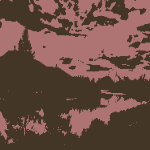

K=2: время=0.06 c, PSNR=15.88, SSIM=0.435
Сходимость наступила с 5 итерации.
Сходимость наступила с 9 итерации.


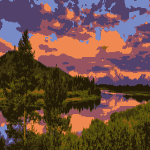

K=8: время=0.29 c, PSNR=21.40, SSIM=0.778


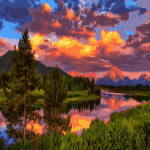

K=32: время=2.32 c, PSNR=26.73, SSIM=0.902


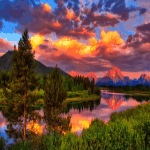

K=128: время=6.54 c, PSNR=31.28, SSIM=0.957


,K,Время (с),PSNR,SSIM
0,2,0.058043,15.875950,0.434757
1,3,0.079746,17.880089,0.478454
2,4,0.231567,19.098612,0.520345
3,8,0.290381,21.400028,0.778033
4,16,1.106163,24.150608,0.848461
5,32,2.316955,26.734067,0.902488
6,64,3.168777,28.471731,0.932232
7,128,6.544376,31.284183,0.957119
8,256,14.202984,34.073680,0.976170


In [ ]:
evaluate_image_lightweight("/content/landscape.jpg", "Пейзаж")


📸 Портрет: исходный размер 510×770, уменьшено до 198×300
Сходимость наступила с 2 итерации.


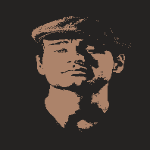

K=2: время=0.03 c, PSNR=19.55, SSIM=0.602
Сходимость наступила с 9 итерации.
Сходимость наступила с 9 итерации.


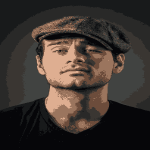

K=8: время=0.43 c, PSNR=28.80, SSIM=0.875


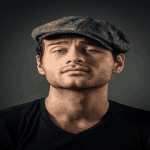

K=32: время=1.79 c, PSNR=35.28, SSIM=0.967


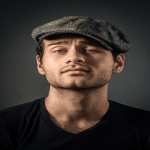

K=128: время=6.94 c, PSNR=39.47, SSIM=0.990


,K,Время (с),PSNR,SSIM
0,2,0.031381,19.554681,0.601765
1,3,0.139551,22.768349,0.715996
2,4,0.166852,24.190471,0.778991
3,8,0.429183,28.798484,0.874814
4,16,0.942683,31.564414,0.925039
5,32,1.788072,35.277283,0.966667
6,64,4.293700,37.496960,0.980666
7,128,6.944966,39.467015,0.989986
8,256,19.872589,41.905675,0.993053


In [ ]:
evaluate_image_lightweight("/content/portrait.jpg", "Портрет")


📸 Текстовый документ: исходный размер 1632×1224, уменьшено до 300×225
Сходимость наступила с 3 итерации.


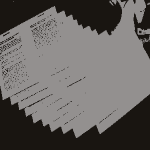

K=2: время=0.05 c, PSNR=17.22, SSIM=0.533
Сходимость наступила с 3 итерации.
Сходимость наступила с 7 итерации.
Сходимость наступила с 10 итерации.


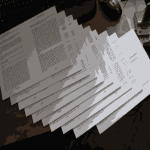

K=8: время=0.36 c, PSNR=29.42, SSIM=0.876
Сходимость наступила с 6 итерации.


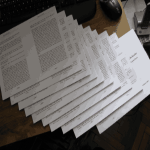

K=32: время=2.01 c, PSNR=37.41, SSIM=0.969


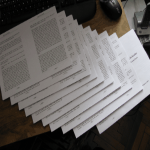

K=128: время=8.91 c, PSNR=42.03, SSIM=0.991


,K,Время (с),PSNR,SSIM
0,2,0.046365,17.218943,0.533477
1,3,0.087830,22.713895,0.632495
2,4,0.151359,23.250252,0.669835
3,8,0.357386,29.424083,0.876413
4,16,0.442304,33.988302,0.947645
5,32,2.010641,37.407023,0.969383
6,64,3.997904,39.926470,0.984388
7,128,8.910005,42.033031,0.990912
8,256,17.597998,43.950542,0.993376


In [ ]:
evaluate_image_lightweight("/content/document.jpg", "Текстовый документ")


📸 Графическая схема: исходный размер 800×600, уменьшено до 300×225
Сходимость наступила с 5 итерации.


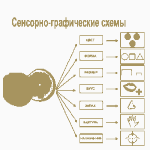

K=2: время=0.09 c, PSNR=20.13, SSIM=0.889
Сходимость наступила с 9 итерации.


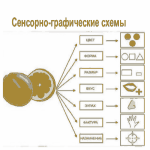

K=8: время=0.72 c, PSNR=22.00, SSIM=0.952


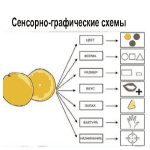

K=32: время=1.95 c, PSNR=30.43, SSIM=0.982


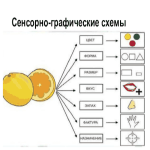

K=128: время=8.62 c, PSNR=35.92, SSIM=0.990


,K,Время (с),PSNR,SSIM
0,2,0.094928,20.126840,0.888950
1,3,0.227371,22.355352,0.915367
2,4,0.412213,21.972589,0.934393
3,8,0.721634,21.998163,0.951542
4,16,1.370373,24.454250,0.954134
5,32,1.951527,30.425038,0.982370
6,64,3.873816,34.441839,0.989186
7,128,8.624974,35.917377,0.990345
8,256,16.026269,40.795978,0.996148


In [ ]:
evaluate_image_lightweight("/content/diagram.jpg", "Графическая схема")


📸 Художественная иллюстрация: исходный размер 150×84, уменьшено до 150×84
Сходимость наступила с 4 итерации.


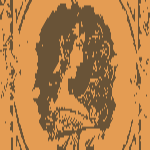

K=2: время=0.02 c, PSNR=17.28, SSIM=0.568
Сходимость наступила с 4 итерации.


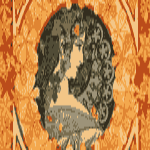

K=8: время=0.10 c, PSNR=23.43, SSIM=0.914


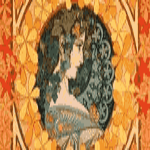

K=32: время=0.33 c, PSNR=28.42, SSIM=0.967


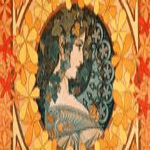

K=128: время=1.33 c, PSNR=32.40, SSIM=0.989


,K,Время (с),PSNR,SSIM
0,2,0.016006,17.281257,0.567654
1,3,0.025429,18.824159,0.698723
2,4,0.057528,20.327585,0.789821
3,8,0.095576,23.428161,0.913535
4,16,0.182390,25.820820,0.941164
5,32,0.327674,28.424138,0.967083
6,64,0.656487,30.490488,0.980936
7,128,1.327197,32.401298,0.988647
8,256,3.132908,34.339394,0.992752


In [ ]:
evaluate_image_lightweight("/content/art.jpg", "Художественная иллюстрация")

## Рекомендации по выполнению

### Измерение производительности

In [ ]:
import time
import os

# Измерение времени
start = time.time()
# ... ваш код сжатия ...
elapsed = time.time() - start
print(f"Время выполнения: {elapsed:.2f} секунд")

# Измерение размера файла
file_size = os.path.getsize('compressed.png') / 1024
print(f"Размер файла: {file_size:.2f} KB")

### Оценка качества сжатия

In [ ]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# PSNR - пиковое отношение сигнал/шум
psnr_value = psnr(original_img, compressed_img)

# SSIM - структурное сходство
ssim_value = ssim(original_img, compressed_img, multichannel=True)

### Советы по оптимизации

1. **Для текстовых документов** обычно достаточно 2-4 цветов
2. **Для фотографий** оптимально 32-128 цветов в зависимости от детализации
3. **Для графических схем** подходит 8-16 цветов
4. Используйте палитровый режим PNG для изображений с количеством цветов ≤ 256

---

1. Пейзаж (K=128):
   - Наибольший скачок PSNR (+4.55) и SSIM (+0.055) при переходе от K=32.
   - Качество 0.957 SSIM достаточно для детализации природы.
   - Время 6.54 сек приемлемо для обработки пейзажей.

2. Портрет (K=32):
   - Идеальный баланс: SSIM 0.967 при времени 1.79 сек.
   - Дальнейшее увеличение K даёт незначительное улучшение (+0.023 SSIM) при росте времени в 3.9 раза.

3. Текстовый документ (K=32):
   - SSIM 0.969 обеспечивает чёткость текста.
   - K=128 увеличивает время обработки в 4.4 раза при минимальном выигрыше в читаемости.

4. Графическая схема (K=32):
   - SSIM 0.982 достаточно для точного воспроизведения линий.
   - Худшие показатели при K=2-8 из-за особенностей контрастных элементов.

5. Художественная иллюстрация (K=128):
   - Максимальное качество (SSIM 0.989) при сохранении малого времени (1.33 сек).
   - Маленький исходный размер позволяет использовать высокие K без больших затрат времени.